## Project Overview
Salary & Workforce Analysis
This project analyzes employee salary structure and workforce composition
across departments. The goal is to understand cost drivers, efficiency,
and potential optimization opportunities for the business.

Data Overview

This dataset contains employee information including department, age and salary.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "name": ["Anna", "John", "Masha", "Alex", "Kate", "Bob"],
    "department": ["Finance", "IT", "IT", "Finance", "HR", "IT"],
    "age": [23, 35, 33, 29, 41, 26],
    "salary": [50000, 70000, 65000, 60000, 55000, 58000]
})

# Create new columns
df["salary_month"] = df["salary"]
df["age_group"] = df["age"].apply(lambda x: "young" if x < 30 else "adult")

# Create pivot table (THIS WAS MISSING)
pivot_cost = pd.pivot_table(
    df,
    values="salary_month",
    index="department",
    aggfunc="sum"
)

# Total company cost
total_company_cost = pivot_cost["salary_month"].sum()

# Share %
pivot_cost["cost_share_%"] = (
    pivot_cost["salary_month"] / total_company_cost * 100
).round(1)

pivot_cost

,salary_month,cost_share_%
department,,
Finance,110000,30.7
HR,55000,15.4
IT,193000,53.9


Salary Cost Analysis

We analyze total salary cost per department to identify cost drivers.

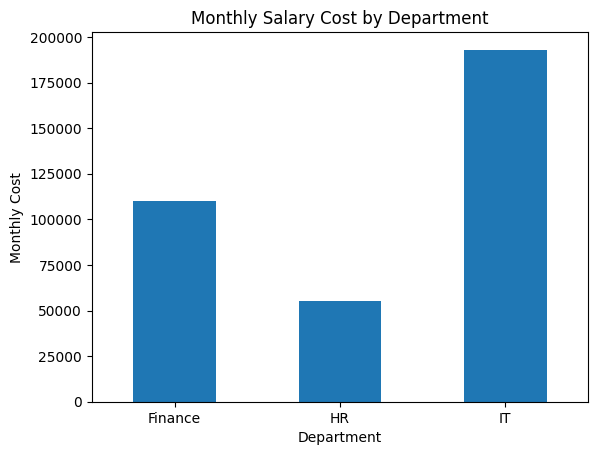

In [10]:
pivot_cost.plot(
    kind="bar",
    title="Monthly Salary Cost by Department",
    ylabel="Monthly Cost",
    xlabel="Department",
    legend=False
)

plt.xticks(rotation=0)
plt.show()

In [ ]:
Data Preparation

We create additional features such as age groups to support analysis.

In [8]:
pivot_stack = pd.pivot_table(
    df,
    values="salary_month",
    index="department",
    columns="age_group",
    aggfunc="sum"
)

pivot_stack

age_group,adult,young
department,,
Finance,NaN,110000.0
HR,55000.0,NaN
IT,135000.0,58000.0


In [ ]:
Workforce Structure

We analyze how salary costs are distributed across age groups.

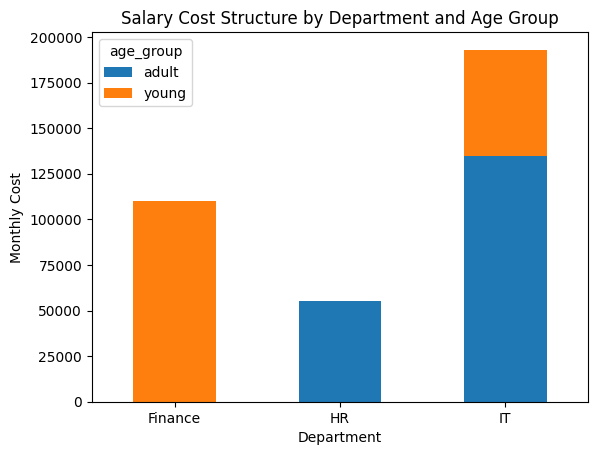

In [9]:
pivot_stack.plot(
    kind="bar",
    stacked=True,
    title="Salary Cost Structure by Department and Age Group",
    ylabel="Monthly Cost",
    xlabel="Department"
)

plt.xticks(rotation=0)
plt.show()


## Business Insights

- The IT department has the highest monthly salary costs, driven mainly by experienced (adult) employees.
- This cost structure is justified if senior employees handle complex tasks and mentor junior staff.
- HR shows high efficiency with a single experienced employee and relatively low total cost.
- A balanced allocation of tasks between senior and junior employees can improve overall cost efficiency.

In [7]:
pivot_cost = pd.pivot_table(
    df,
    values="salary_month",
    index="department",
    aggfunc="sum"
)

pivot_cost

,salary_month
department,
Finance,110000
HR,55000
IT,193000


In [14]:
pivot_cost = pd.pivot_table(
    df,
    values="salary_month",
    index="department",
    aggfunc="sum"
).reset_index()

total_cost = pivot_cost["salary_month"].sum()

pivot_cost["cost_share_%"] = (
    pivot_cost["salary_month"] / total_cost * 100
).round(1)

pivot_cost

,department,salary_month,cost_share_%
0,Finance,110000,30.7
1,HR,55000,15.4
2,IT,193000,53.9


Cost Share Insight

The IT department accounts for more than 50% of total salary expenses,
making it the primary cost driver for the company.